In [66]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully!")

Libraries imported successfully!


 Import Libraries

Import the required Python libraries for data analysis, visualization, preprocessing, and machine learning.

In [67]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


 Load Dataset

Load the Telco Customer Churn dataset and store it in a Pandas DataFrame.

In [68]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


 Understand the Dataset

Explore the dataset structure, columns, data types, missing values, and basic statistics.

In [69]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [70]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 7043
Number of columns: 21


In [71]:
print("Column Names:")
print(df.columns.tolist())


Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


 Data Cleaning

Clean missing values, convert data types, remove duplicates, and remove unnecessary columns.

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [73]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [74]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [75]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [76]:
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [77]:
print(df["TotalCharges"].dtype)

object


In [78]:
df = df.dropna()

In [79]:
print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (7043, 21)


In [80]:
df = df.drop_duplicates()

In [81]:
df = df.drop("customerID", axis=1)

In [82]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


 Exploratory Data Analysis

Analyze customer churn and identify important factors that may influence customer decisions.

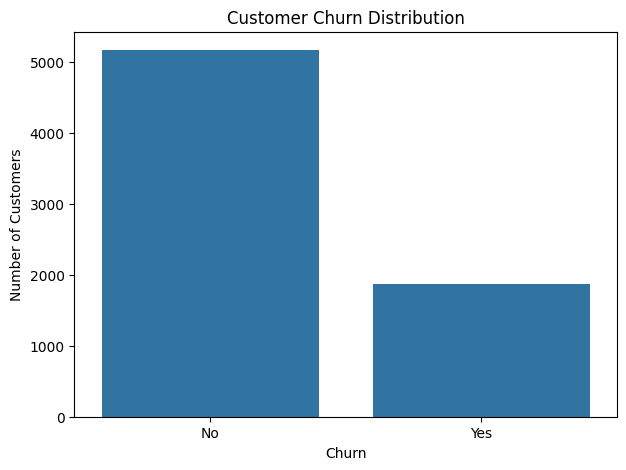

In [83]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [84]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print(churn_percentage)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


 Churn Distribution

Analyze the number of customers who stayed and customers who churned.

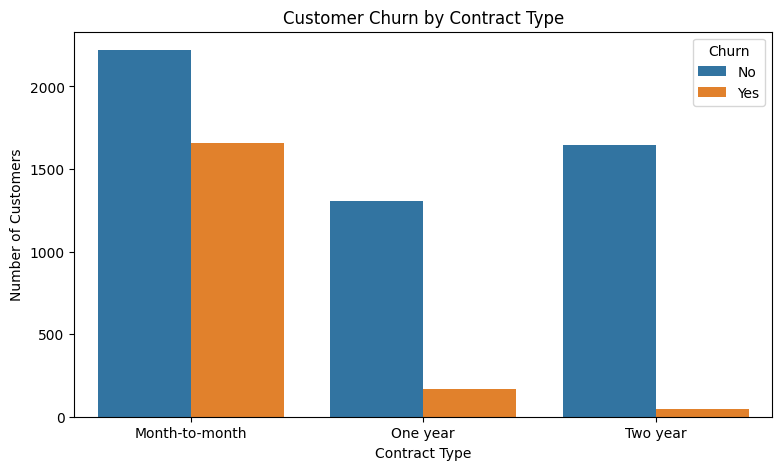

In [85]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

 Churn by Contract

Analyze the relationship between contract type and customer churn.

 Churn vs Tenure

Analyze whether customer tenure is related to churn.

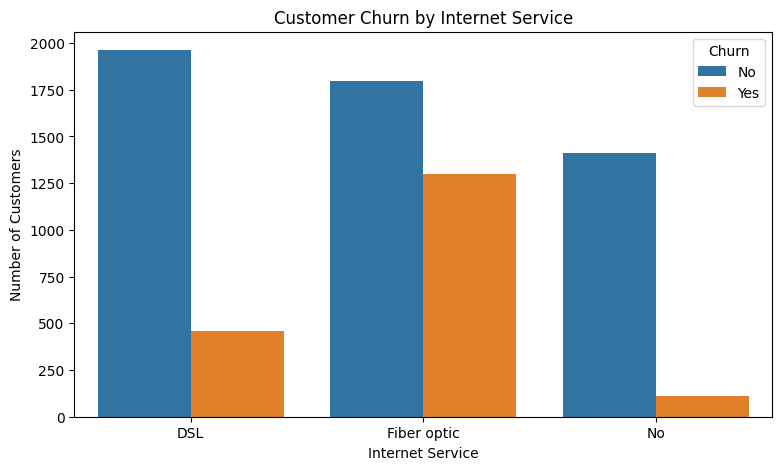

In [86]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

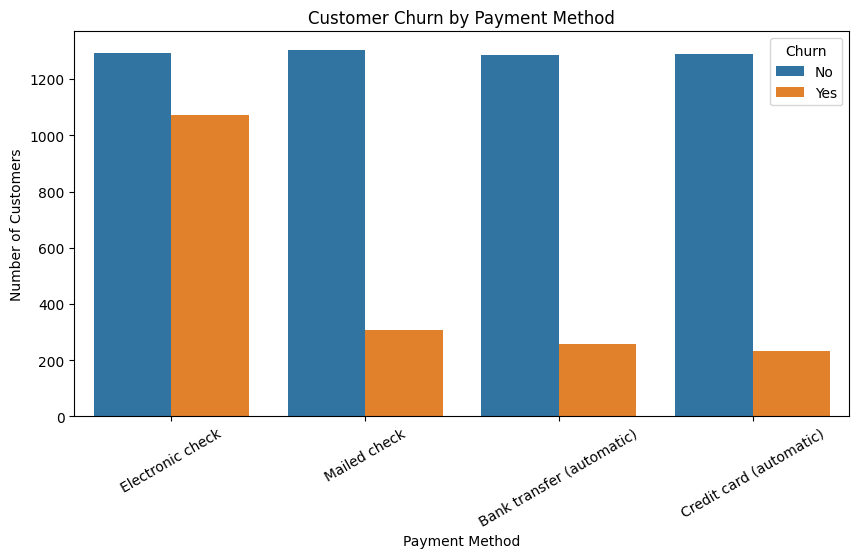

In [87]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

plt.show()

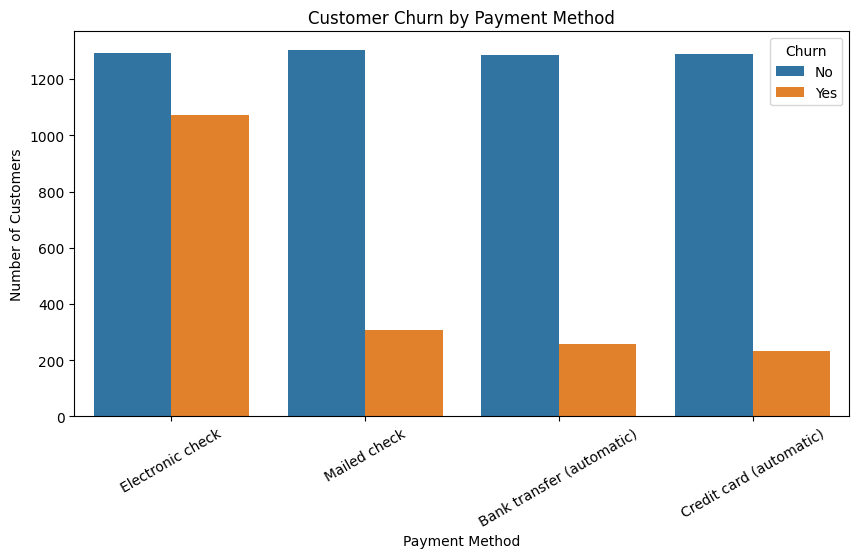

In [88]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

plt.show()

 Feature Preparation

Convert categorical data into numerical values and separate input features from the target variable.

In [89]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [90]:
print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [91]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [92]:
X = pd.get_dummies(X, drop_first=True)

In [93]:
print("Shape of X:", X.shape)

X.head()

Shape of X: (7043, 6559)


,SeniorCitizen,tenure,MonthlyCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,TotalCharges_995.35,TotalCharges_996.45,TotalCharges_996.85,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9
0,0,1,29.85,False,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,34,56.95,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0,2,53.85,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0,45,42.30,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0,2,70.70,False,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False


 Train-Test Split

Split the dataset into training data and testing data to build and evaluate the model.

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [95]:
print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 5634
Testing records: 1409


 Feature Scaling

Standardize the numerical features so they are suitable for machine learning.

In [96]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [97]:
scaler.fit_transform(X_train)

array([[-0.44177295,  0.10237124, -0.52197565, ..., -0.01332386,
        -0.01332386, -0.01332386],
       [-0.44177295, -0.71174346,  0.33747781, ..., -0.01332386,
        -0.01332386, -0.01332386],
       [-0.44177295, -0.79315493, -0.80901319, ..., -0.01332386,
        -0.01332386, -0.01332386],
       ...,
       [ 2.2636062 , -0.30468611,  1.25666162, ..., -0.01332386,
        -0.01332386, -0.01332386],
       [-0.44177295, -0.34539184, -1.47766135, ..., -0.01332386,
        -0.01332386, -0.01332386],
       [-0.44177295, -1.07809507, -1.46936546, ..., -0.01332386,
        -0.01332386, -0.01332386]])

In [98]:
scaler.transform(X_test)

array([[-0.44177295,  1.60848343,  1.62997635, ..., -0.01332386,
        -0.01332386, -0.01332386],
       [ 2.2636062 , -0.9966836 ,  1.16872526, ..., -0.01332386,
        -0.01332386, -0.01332386],
       [-0.44177295,  0.34660565,  0.44532428, ..., -0.01332386,
        -0.01332386, -0.01332386],
       ...,
       [-0.44177295, -1.11880081, -1.46936546, ..., -0.01332386,
        -0.01332386, -0.01332386],
       [-0.44177295,  0.95719167, -1.50088982, ..., -0.01332386,
        -0.01332386, -0.01332386],
       [-0.44177295,  1.60848343,  0.18317439, ..., -0.01332386,
        -0.01332386, -0.01332386]])

In [99]:
model = LogisticRegression(max_iter=1000)

In [100]:
model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


In [101]:
y_pred = model.predict(X_test_scaled)

In [102]:
print(y_pred[:20])

[0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0]


 Model Building

Build a Logistic Regression model to predict customer churn.

In [103]:
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

 Churn Probability

Calculate the probability of each customer churning.

In [104]:
y_probability = model.predict_proba(X_test_scaled)[:, 1]

print(y_probability[:10])

[2.40150316e-03 7.58034606e-01 1.32081774e-04 1.44989380e-01
 1.08338959e-03 6.47282466e-01 5.09166358e-01 5.05037098e-04
 3.42887955e-06 4.85117074e-01]


In [105]:
prediction_label = np.where(
    y_probability >= 0.5,
    "Likely to Churn",
    "Likely to Stay"
)

print(prediction_label[:10])

['Likely to Stay' 'Likely to Churn' 'Likely to Stay' 'Likely to Stay'
 'Likely to Stay' 'Likely to Churn' 'Likely to Churn' 'Likely to Stay'
 'Likely to Stay' 'Likely to Stay']


In [106]:
prediction_results = pd.DataFrame({
    "Actual_Churn": y_test.values,
    "Churn_Probability": y_probability,
    "Predicted_Churn": y_pred,
    "Prediction": prediction_label
})

prediction_results.head(20)

,Actual_Churn,Churn_Probability,Predicted_Churn,Prediction
0,0,0.002402,0,Likely to Stay
1,0,0.758035,1,Likely to Churn
2,0,0.000132,0,Likely to Stay
3,0,0.144989,0,Likely to Stay
4,0,0.001083,0,Likely to Stay
5,0,0.647282,1,Likely to Churn
6,0,0.509166,1,Likely to Churn
7,0,0.000505,0,Likely to Stay
8,0,0.000003,0,Likely to Stay
9,1,0.485117,0,Likely to Stay


 Model Evaluation

Evaluate the model using accuracy, precision, recall, F1-score, and ROC-AUC.

In [107]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.7764371894960965
Accuracy (%): 77.64371894960965


In [108]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.5930599369085173


In [109]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.5026737967914439


In [110]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.5441389290882779


In [111]:
roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8025988788137126


In [112]:
print("MODEL PERFORMANCE")
print("-------------------------")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

MODEL PERFORMANCE
-------------------------
Accuracy : 0.7764371894960965
Precision: 0.5930599369085173
Recall   : 0.5026737967914439
F1 Score : 0.5441389290882779
ROC-AUC  : 0.8025988788137126


Confusion Matrix

Analyze correct and incorrect churn predictions using the confusion matrix.

In [113]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[906 129]
 [186 188]]


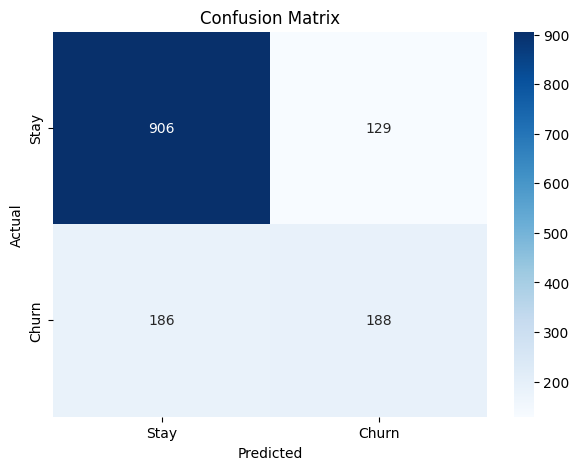

In [114]:
plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stay", "Churn"],
    yticklabels=["Stay", "Churn"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [115]:
tn, fp, fn, tp = cm.ravel()

print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

True Negative : 906
False Positive: 129
False Negative: 186
True Positive : 188


In [116]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute_Coefficient
23,Contract_One year,-1.111520,1.111520
22,StreamingMovies_Yes,1.003931,1.003931
1,tenure,-0.978646,0.978646
27,PaymentMethod_Electronic check,0.925098,0.925098
25,PaperlessBilling_Yes,0.724422,0.724422
9,InternetService_Fiber optic,0.713462,0.713462
24,Contract_Two year,-0.701499,0.701499
28,PaymentMethod_Mailed check,0.500785,0.500785
2,MonthlyCharges,0.423186,0.423186
14,OnlineBackup_Yes,-0.404540,0.404540


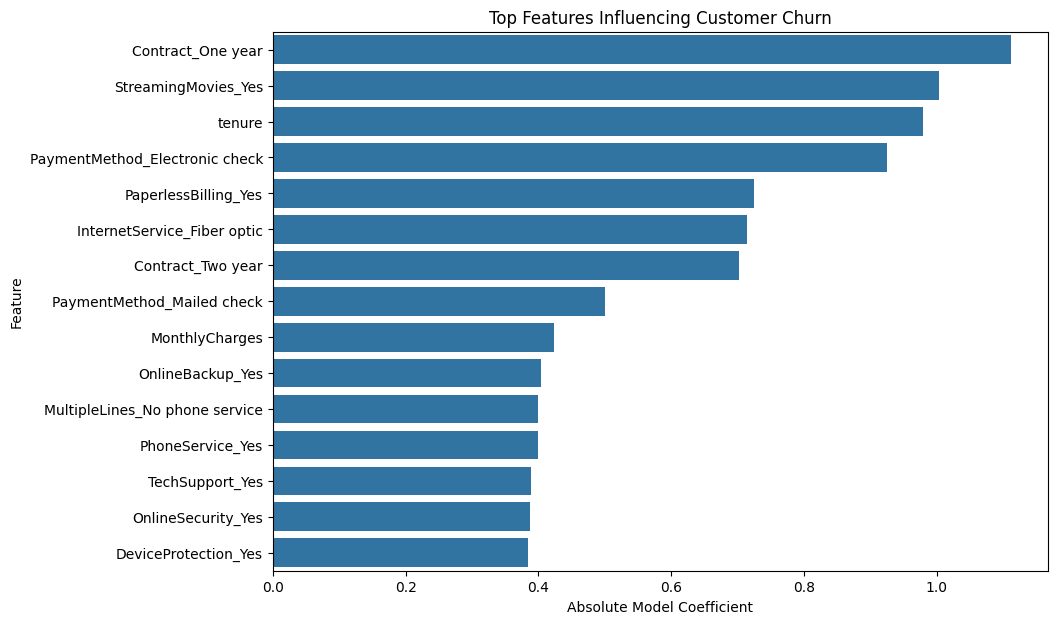

In [117]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10,7))

sns.barplot(
    data=top_features,
    x="Absolute_Coefficient",
    y="Feature"
)

plt.title("Top Features Influencing Customer Churn")
plt.xlabel("Absolute Model Coefficient")
plt.ylabel("Feature")

plt.show()

 Prediction for an Unseen Customer

A new customer record that was not included in the training or testing dataset is created.

The same preprocessing steps used during model training are applied to the new customer.

The model then provides:

1. The estimated probability of churn.
2. The predicted churn classification.

This demonstrates how the model could be used in a real-world telecom environment to assess the churn risk of a new or existing customer.

In [118]:
new_customer = pd.DataFrame({
    "gender": ["Female"],
    "SeniorCitizen": [0],
    "Partner": ["Yes"],
    "Dependents": ["No"],
    "tenure": [5],
    "PhoneService": ["Yes"],
    "MultipleLines": ["No"],
    "InternetService": ["Fiber optic"],
    "OnlineSecurity": ["No"],
    "OnlineBackup": ["No"],
    "DeviceProtection": ["No"],
    "TechSupport": ["No"],
    "StreamingTV": ["No"],
    "StreamingMovies": ["No"],
    "Contract": ["Month-to-month"],
    "PaperlessBilling": ["Yes"],
    "PaymentMethod": ["Electronic check"],
    "MonthlyCharges": [80.0],
    "TotalCharges": [400.0]
})

new_customer

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,5,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,80.0,400.0


In [119]:
new_customer_encoded = pd.get_dummies(
    new_customer,
    drop_first=True
)

In [120]:
new_customer_encoded = new_customer_encoded.reindex(
    columns=X.columns,
    fill_value=0
)

In [121]:
new_customer_scaled = scaler.transform(
    new_customer_encoded
)

In [122]:
new_probability = model.predict_proba(
    new_customer_scaled
)[0][1]

print(
    "Churn Probability:",
    new_probability
)

Churn Probability: 0.022289120609225367


In [123]:
new_probability = model.predict_proba(
    new_customer_scaled
)[0][1]

print(
    "Churn Probability:",
    new_probability
)

Churn Probability: 0.022289120609225367


In [124]:
print(
    "Churn Probability:",
    round(new_probability * 100, 2),
    "%"
)

Churn Probability: 2.23 %


In [125]:
new_prediction = model.predict(
    new_customer_scaled
)[0]

if new_prediction == 1:
    print("Prediction: Likely to Churn")
else:
    print("Prediction: Likely to Stay")

Prediction: Likely to Stay


Conclusion

The Telco Customer Churn dataset was analyzed to understand customer behavior and identify factors associated with churn.

A Logistic Regression model was developed to predict whether customers are likely to stay or leave the telecom company. The model also provides a probability of churn, allowing the company to identify high-risk customers.

The evaluation results show how effectively the model identifies actual churn customers and avoids incorrectly flagging customers who are likely to stay.

From a business perspective, the model can support focused customer retention programs by helping the company prioritize customers who have a higher risk of churn.

Future improvements could include threshold optimization, testing additional machine learning algorithms, hyperparameter tuning, and incorporating additional customer behavior or usage data.